In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.datasets import load_digits

In [3]:
digits = load_digits()

In [4]:
digits.data.shape

(1797, 64)

In [5]:
digits.target_names

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [6]:
digits.images[0].shape

(8, 8)

(1797, 65)
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


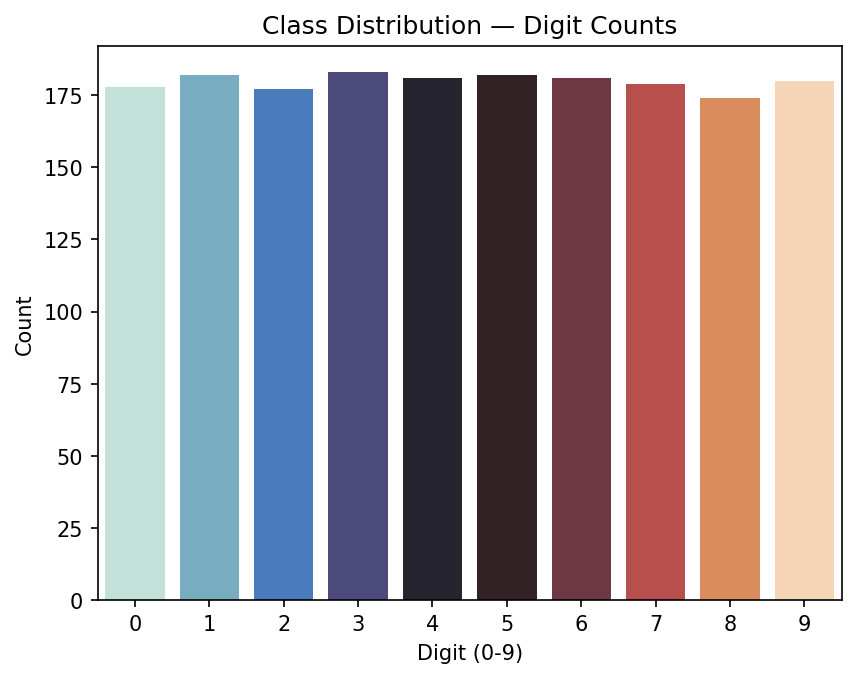

In [7]:
# Handwritten Digit Recognition (MNIST) – classify digits 0–9 from images
# Visualizing the images

plot_data           = pd.DataFrame(digits.data,columns=digits.feature_names)
plot_data['target'] = digits.target

print(plot_data.shape)                                    # (1797, 65)
print(plot_data['target'].value_counts().sort_index())    # ~178-183 each

plt.figure(dpi=150)
sns.countplot(
    data=plot_data,          # ← use plot_data NOT data
    x='target',
    hue='target',
    palette='icefire',
    legend=False
)
plt.title("Class Distribution — Digit Counts")
plt.xlabel('Digit (0-9)')
plt.ylabel('Count')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score

In [9]:
X = digits.data
y = digits.target

In [10]:
print(f"X type  : {type(X)}")        # Should be numpy.ndarray
print(f"X shape : {X.shape}")        # (1797, 64)
print(f"y shape : {y.shape}")        # (1797,)
print(f"Classes : {np.unique(y)}")   # [0 1 2 3 4 5 6 7 8 9]

X type  : <class 'numpy.ndarray'>
X shape : (1797, 64)
y shape : (1797,)
Classes : [0 1 2 3 4 5 6 7 8 9]


In [11]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [12]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
models = {
    'Logistic regression' : LogisticRegression(max_iter=1000),
    'Decision Tree' : DecisionTreeClassifier(max_depth=5,random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100,random_state=42),
    'KNN' : KNeighborsClassifier(n_neighbors=5),
    'SVC' : SVC(kernel='rbf',probability=True,random_state=42),
    'Naive Bayes' : GaussianNB()
    }

results = []

for model_names ,model in models.items():
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)

    results.append ({
        'model' : model_names,
        'Accuracy' : round(accuracy_score(y_test,y_pred),4),
        'Precision' : round(precision_score(y_test,y_pred , average='weighted',zero_division=0) ,4),
        'Recall' : round(recall_score(y_test,y_pred , average='weighted',zero_division=0),4),
        'F1 score' : round(f1_score(y_test,y_pred , average='weighted',zero_division=0),4),
    })
    print(f"{model_names} Trained.")

results_df = pd.DataFrame(results)
print("\n========== MODEL COMPARISON ==========")
print(results_df.to_string(index=False))

print("\n🏆 Best Model by Accuracy:")
best = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"   {best['model']} → Accuracy: {best['Accuracy']}")




Logistic regression Trained.
Decision Tree Trained.
Random Forest Trained.
KNN Trained.
SVC Trained.
Naive Bayes Trained.

========== MODEL COMPARISON ==========
              model  Accuracy  Precision  Recall  F1 score
Logistic regression    0.9722     0.9725  0.9722    0.9723
      Decision Tree    0.6639     0.7316  0.6639    0.6658
      Random Forest    0.9722     0.9726  0.9722    0.9722
                KNN    0.9750     0.9750  0.9750    0.9748
                SVC    0.9806     0.9809  0.9806    0.9805
        Naive Bayes    0.7667     0.8298  0.7667    0.7638

🏆 Best Model by Accuracy:
   SVC → Accuracy: 0.9806


In [ ]:

import pickle
with open('digit_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✅ Saved → digit_model.pkl")

with open('digit_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Saved → digit_scaler.pkl")

with open('digit_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('digit_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print("\n✅ Pickle files loaded successfully!")


✅ Saved → digit_model.pkl
✅ Saved → digit_scaler.pkl

✅ Pickle files loaded successfully!


In [17]:

#prediction
sample        = X_test[0].reshape(1, -1)   # already scaled
prediction    = loaded_model.predict(sample)
probability   = loaded_model.predict_proba(sample)

print("\n========== SAMPLE PREDICTION ==========")
print(f"Predicted Digit : {prediction[0]}")
print(f"Actual Digit    : {y_test[0]}")
print(f"Confidence      : {round(max(probability[0])*100, 2)}%")


========== SAMPLE PREDICTION ==========
Predicted Digit : 6
Actual Digit    : 6
Confidence      : 100.0%
